In [207]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [209]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/wcont_full_1E6'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/wcont_full_1E7'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/wcont_full_1E7_closer'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/wcont_full_1E7_closer_Anet_g1'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/2023swp'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/2023swp_red_1'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/2023swp_red_2'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/2023swp_red_2_logit'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/2023swp_red_2_sustain'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/2023swp_red_3'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/test'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/2023_indiv_test'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/2023_indiv_2E7'

In [210]:
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)
scenario_name = "11_05_nstdn_red"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
df = pd.read_csv(os.path.join(post_path, 'parameters_best_0.csv'))
range_real = [0, 1, 3, 4, 6, 7, 9, 10, 11, 12, 13]
range_alive = [1, 4, 9, 10, 11, 12, 13]
range_dead = [0, 3, 6, 7]

In [211]:
df_dead_list = []
for id in range_dead:
    df =pd.read_csv(os.path.join(post_path,f'parameters_best_{id}.csv')).sort_values(by=[f't{id}'])
    df.reset_index(inplace=True)
    df_dead_list.append(df)
df_alive = pd.read_csv(os.path.join(post_path,f'parameters_best_mean_alive.csv')).sort_values(by=['alive_mean'])
df_alive.reset_index(inplace=True)

In [212]:
variables = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta', 'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation','g_bark' ]

In [213]:
dfs = df_dead_list[3][variables][0:1000]
#dfs = df_alive[variables][0:1000]

In [214]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score


In [215]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(dfs)

KMeans(n_clusters=3, random_state=0)

<Axes: ylabel='stem_hydraulic_capacitance'>

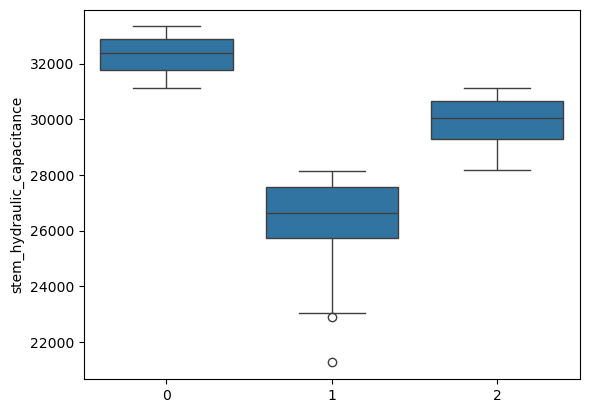

In [216]:
sns.boxplot(x = kmeans.labels_, y = dfs['stem_hydraulic_capacitance'])


In [217]:
K = range(2, 8)
fits = []
score = []


for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(dfs)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(dfs, model.labels_, metric='euclidean'))

<Axes: >

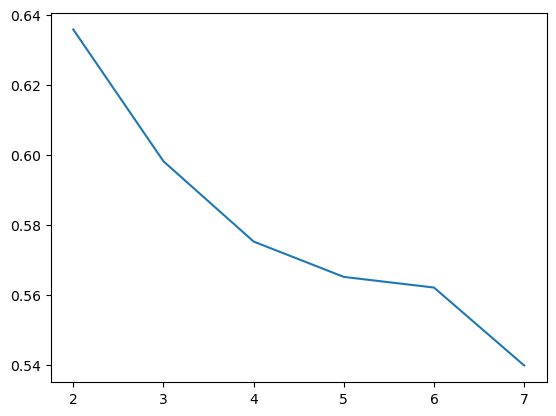

In [218]:
sns.lineplot(x = K, y = score)

In [219]:
kmeans = KMeans(n_clusters = 6, random_state = 0, n_init='auto')
kmeans.fit(dfs)

KMeans(n_clusters=6, random_state=0)

In [220]:
len(variables)

17

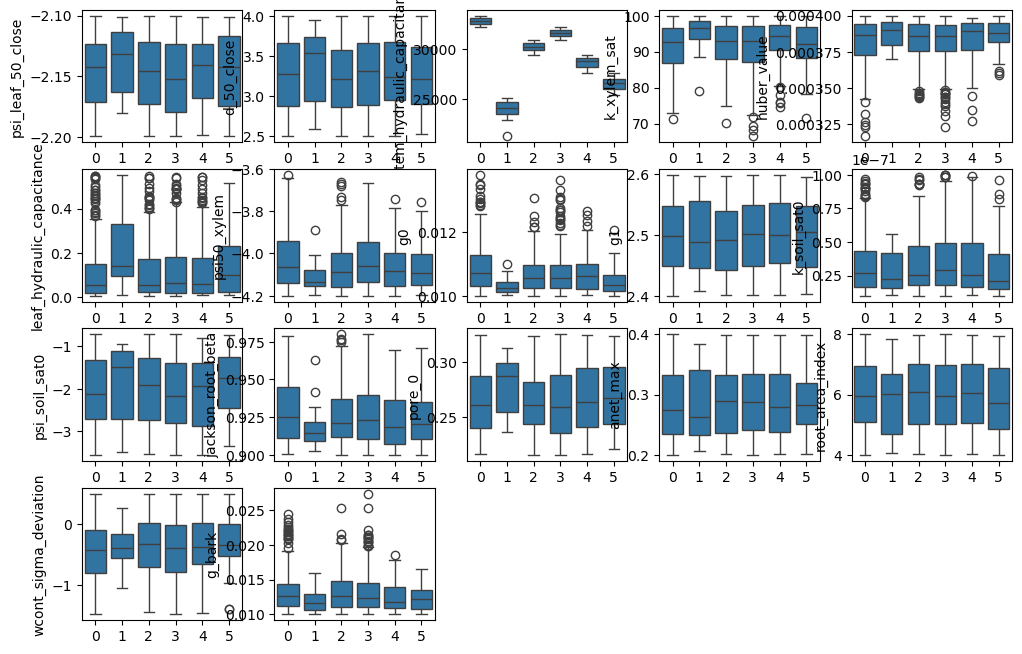

In [221]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(variables)+1), variables):
    ax = fig.add_subplot(5,5, index)
    sns.boxplot(x = kmeans.labels_, y = dfs[var], ax=ax)

<Axes: >

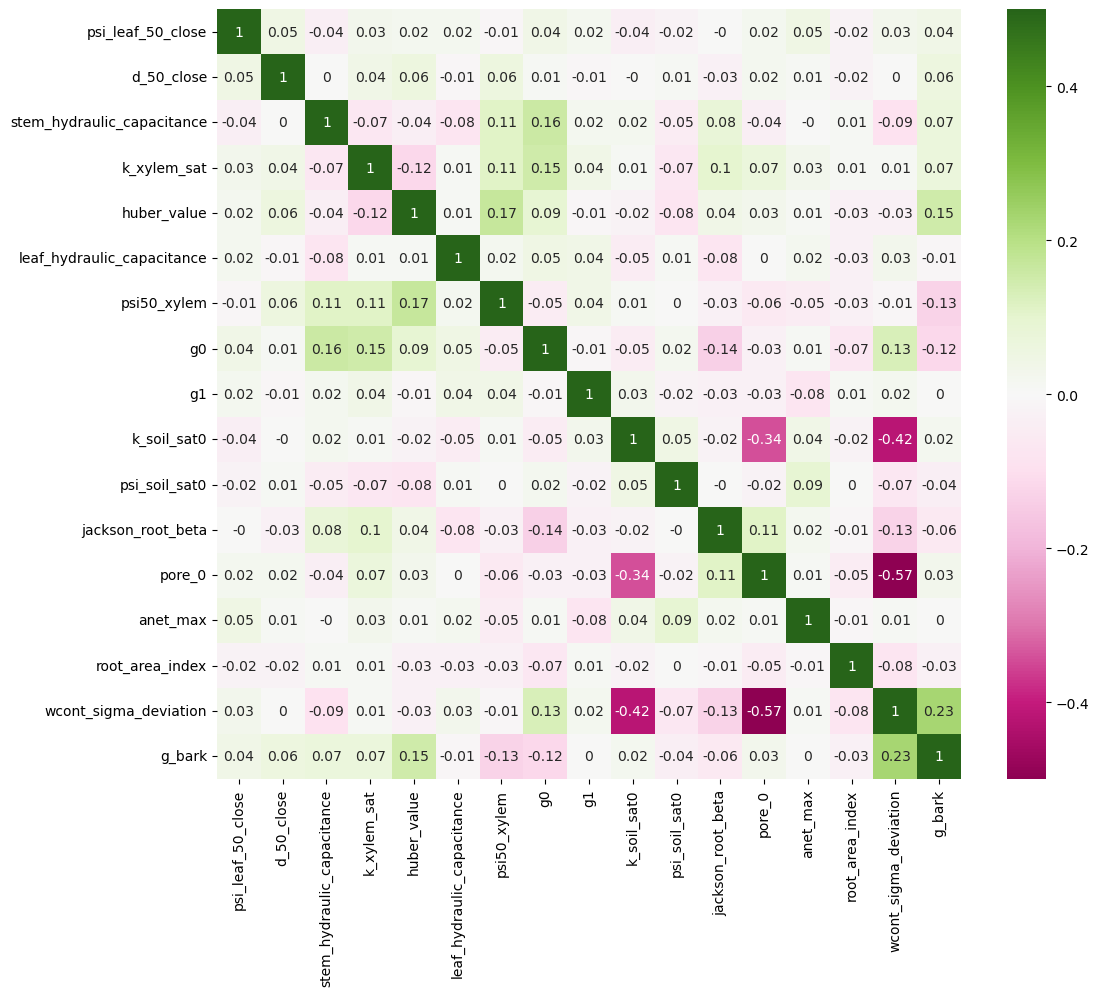

In [222]:
corr_matrix = dfs.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")

<Axes: ylabel='stem_hydraulic_capacitance'>

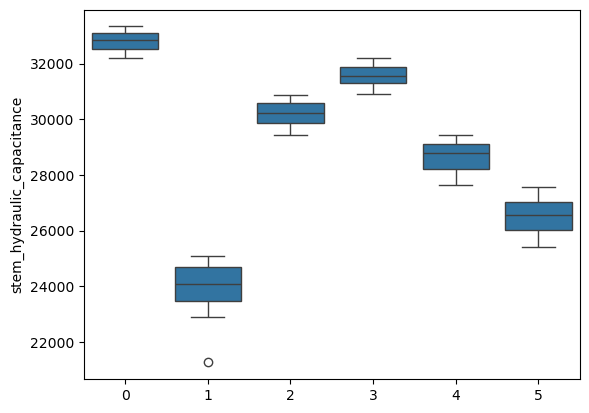

In [223]:
sns.boxplot(x = kmeans.labels_, y = dfs['stem_hydraulic_capacitance'])

<Axes: ylabel='huber_value'>

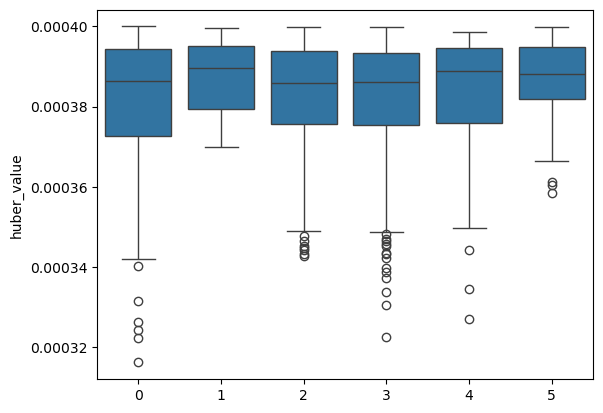

In [224]:
sns.boxplot(x = kmeans.labels_, y = dfs['huber_value'])

<Axes: ylabel='leaf_hydraulic_capacitance'>

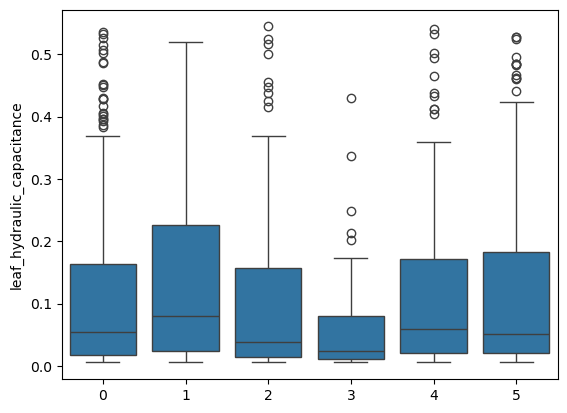

In [47]:
sns.boxplot(x=kmeans.labels_, y=dfs['leaf_hydraulic_capacitance'])

In [338]:
dfd = df_dead_list[0][variables][0:1000]
dfd['alive'] = 0
dfa = df_alive[variables][0:1000]
dfa['alive'] = 1
dfcs = pd.concat([dfd, dfa], axis = 0)
dfc = dfcs.drop(['alive'], axis = 1)
dfc=(dfc-dfc.mean())/dfc.std()

In [340]:
dfc

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
0,0.637490,0.485222,0.582615,0.970544,0.851068,-0.754838,-0.423109,-1.061931,1.103244,-1.098919,1.473648,-1.082830,-1.929913,-0.109541,0.004066,0.451160,0.233443
1,0.963511,0.900795,0.879732,1.344043,0.952321,-0.674049,-1.083421,-0.319214,-1.260245,0.150206,0.996921,-0.802646,-1.017888,-1.436323,0.530329,-1.811651,0.001674
2,0.865043,-0.475643,0.810215,1.182079,-0.111117,-0.019214,1.891453,-0.879912,-1.359854,-0.485485,1.611357,-1.143168,-2.197380,-1.292492,0.675691,0.001070,-0.589048
3,0.332099,-0.996789,0.493432,1.337814,0.874920,-0.546765,-0.312834,-0.331325,-1.730915,-1.059029,-0.785525,0.161646,-1.114471,-1.873708,-0.894599,-0.069965,-0.106838
4,1.418031,0.629636,-0.057303,1.005362,0.816562,-0.820273,-0.519772,-0.564454,1.431442,-0.960733,0.072854,-0.571149,-2.077510,-0.832831,0.234909,0.334253,-1.011326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.574822,-1.091520,0.731791,-1.429472,0.719122,0.655925,-0.702581,-0.179340,0.866328,1.738624,-0.013050,1.352069,0.521089,0.321755,-1.225140,0.770593,0.536259
996,0.921816,0.280187,-2.201942,-0.815835,-0.306473,-0.816686,-0.658531,2.511821,-0.981193,1.793172,-1.248769,1.840491,0.342422,0.167372,1.196235,1.090317,2.011952
997,1.649465,0.988282,-0.316736,-0.046245,-1.806215,-0.802728,-0.214220,-0.463716,0.173091,-0.891204,1.513633,-1.347145,0.858477,-0.152091,0.568167,0.843194,-0.238626
998,-1.223309,-0.638526,0.195456,-1.833345,-0.012449,-0.803387,-0.750055,-0.095800,-0.883714,-0.364897,-0.092798,0.464585,1.248805,0.448986,-1.700832,0.959646,0.784456


In [364]:
K = range(2, 12)
fits = []
score = []


for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(dfc)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(dfc, model.labels_, metric='euclidean'))

<Axes: >

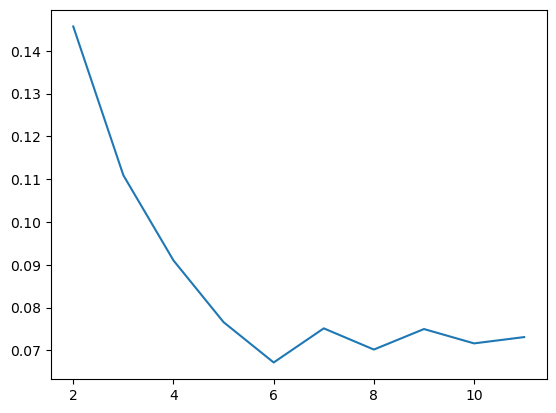

In [365]:
sns.lineplot(x = K, y = score)

In [343]:
nclusters = 6
kmeans = KMeans(n_clusters = nclusters, random_state = 0, n_init='auto')
kmeans.fit(dfc)

KMeans(n_clusters=6, random_state=0)

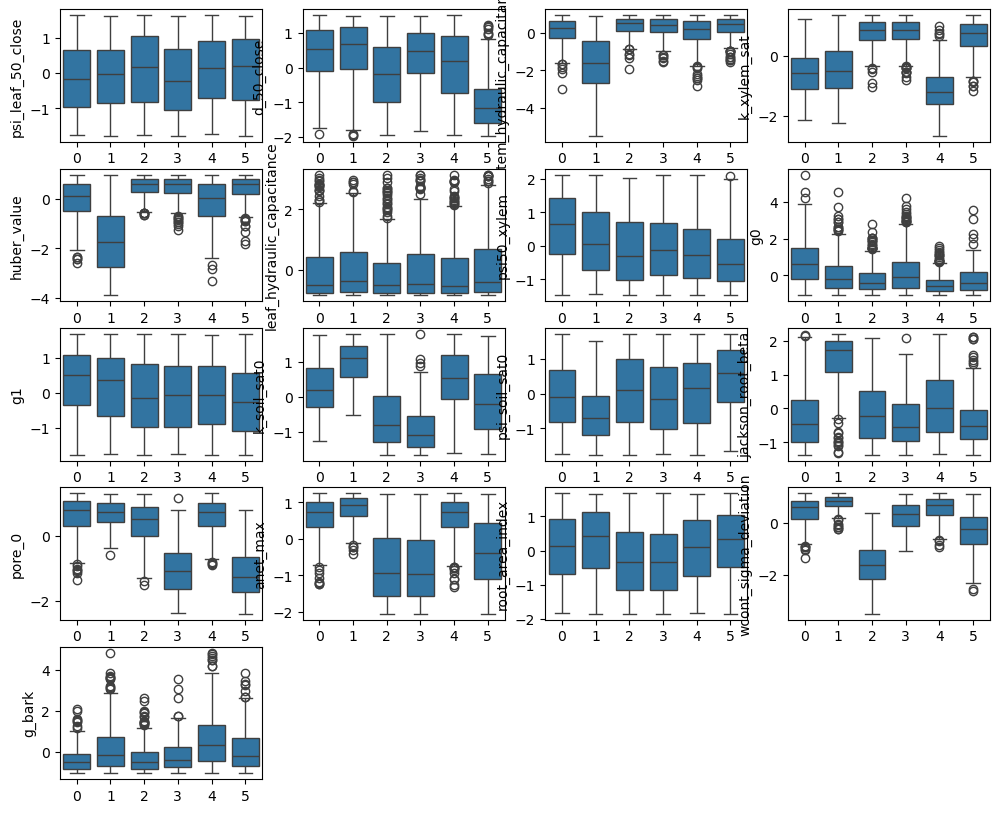

In [344]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(variables)+1), variables):
    ax = fig.add_subplot(5,4, index)
    sns.boxplot(x = kmeans.labels_, y = dfc[var], ax=ax)

In [366]:
 alive_means = [dfcs.loc[kmeans.labels_ == i, 'alive'].mean() for i in range(nclusters)]
 alive_means

[0.9940119760479041,
 1.0,
 0.011695906432748537,
 0.008645533141210375,
 0.9975550122249389,
 0.039634146341463415]

In [346]:
import matplotlib.colors

In [367]:
cvals  = [0.0,  1]
colors = ["red","tab:blue"]

norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

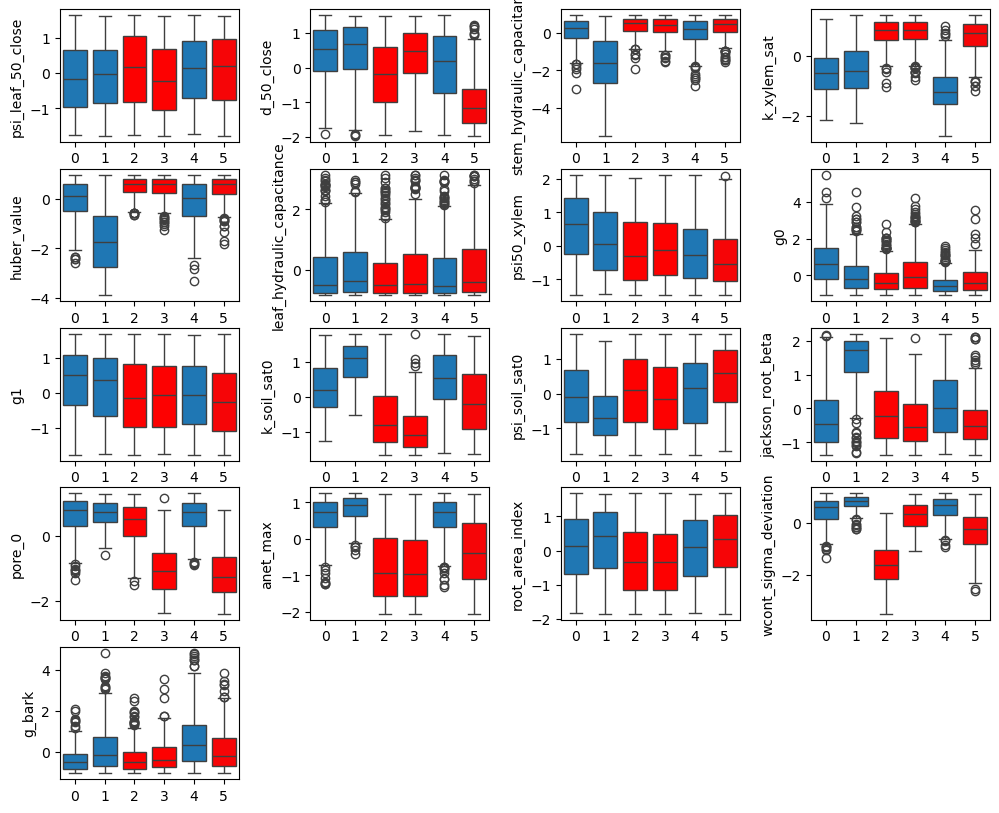

In [368]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(variables)+1), variables):
    ax = fig.add_subplot(5,4, index)
    sns.boxplot(x = kmeans.labels_, y = dfc[var], ax=ax)
    for i in range(nclusters):
        box = ax.patches[i]
        box.set_facecolor(cmap(alive_means[i]))
plt.subplots_adjust(wspace=0.4)

<Axes: >

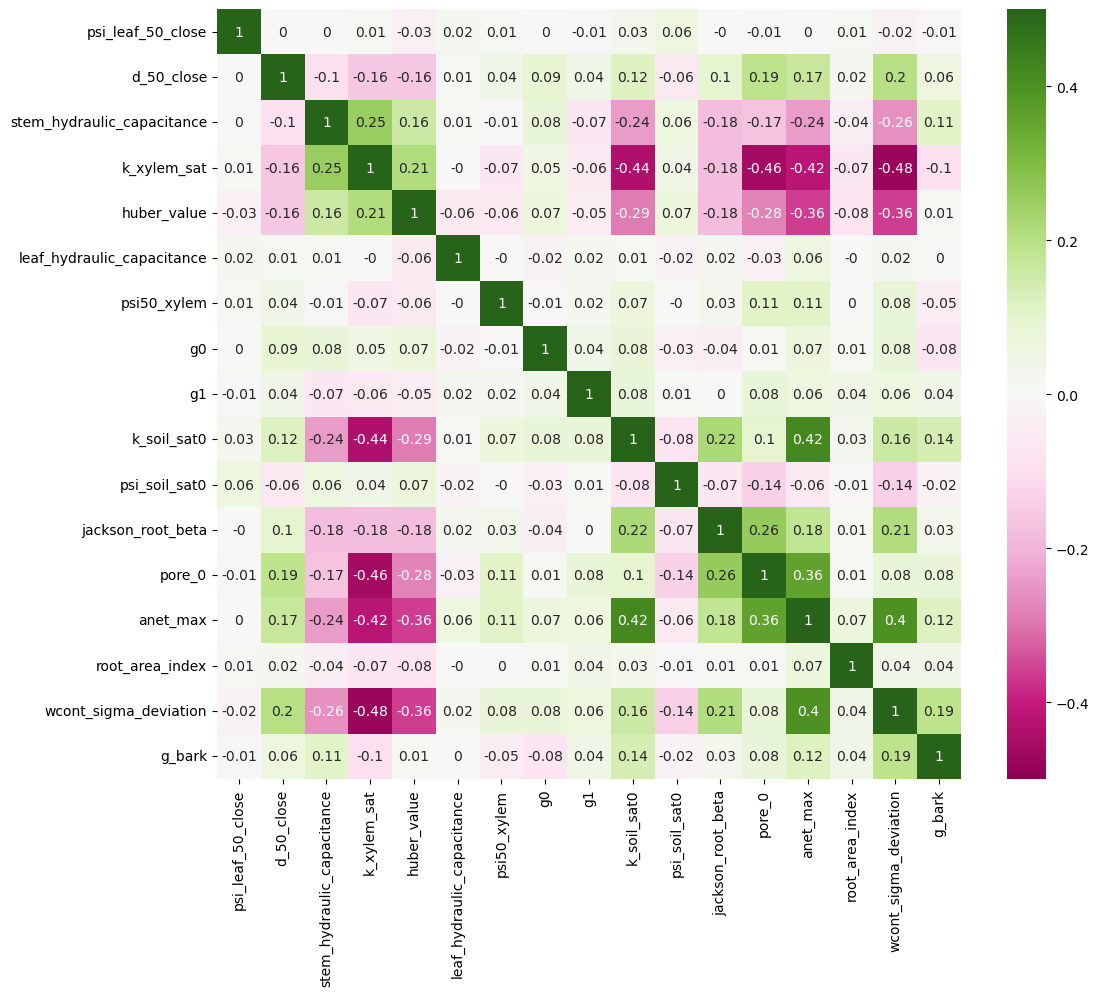

In [369]:
corr_matrix = dfc.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")

In [352]:
dfc

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
0,0.637490,0.485222,0.582615,0.970544,0.851068,-0.754838,-0.423109,-1.061931,1.103244,-1.098919,1.473648,-1.082830,-1.929913,-0.109541,0.004066,0.451160,0.233443
1,0.963511,0.900795,0.879732,1.344043,0.952321,-0.674049,-1.083421,-0.319214,-1.260245,0.150206,0.996921,-0.802646,-1.017888,-1.436323,0.530329,-1.811651,0.001674
2,0.865043,-0.475643,0.810215,1.182079,-0.111117,-0.019214,1.891453,-0.879912,-1.359854,-0.485485,1.611357,-1.143168,-2.197380,-1.292492,0.675691,0.001070,-0.589048
3,0.332099,-0.996789,0.493432,1.337814,0.874920,-0.546765,-0.312834,-0.331325,-1.730915,-1.059029,-0.785525,0.161646,-1.114471,-1.873708,-0.894599,-0.069965,-0.106838
4,1.418031,0.629636,-0.057303,1.005362,0.816562,-0.820273,-0.519772,-0.564454,1.431442,-0.960733,0.072854,-0.571149,-2.077510,-0.832831,0.234909,0.334253,-1.011326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.574822,-1.091520,0.731791,-1.429472,0.719122,0.655925,-0.702581,-0.179340,0.866328,1.738624,-0.013050,1.352069,0.521089,0.321755,-1.225140,0.770593,0.536259
996,0.921816,0.280187,-2.201942,-0.815835,-0.306473,-0.816686,-0.658531,2.511821,-0.981193,1.793172,-1.248769,1.840491,0.342422,0.167372,1.196235,1.090317,2.011952
997,1.649465,0.988282,-0.316736,-0.046245,-1.806215,-0.802728,-0.214220,-0.463716,0.173091,-0.891204,1.513633,-1.347145,0.858477,-0.152091,0.568167,0.843194,-0.238626
998,-1.223309,-0.638526,0.195456,-1.833345,-0.012449,-0.803387,-0.750055,-0.095800,-0.883714,-0.364897,-0.092798,0.464585,1.248805,0.448986,-1.700832,0.959646,0.784456


In [360]:
from sklearn.cluster import HDBSCAN
from sklearn import metrics

db = HDBSCAN(min_samples=2).fit(dfc)

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(dfc, db.labels_,metric='euclidean'):.3f}")

Estimated number of clusters: 2
Estimated number of noise points: 270
Silhouette Coefficient: 0.082


In [361]:
alive_means = [dfcs.loc[db.labels_ == i, 'alive'].mean() for i in range(n_clusters_)]
alive_means

[0.4817391304347826, 1.0]

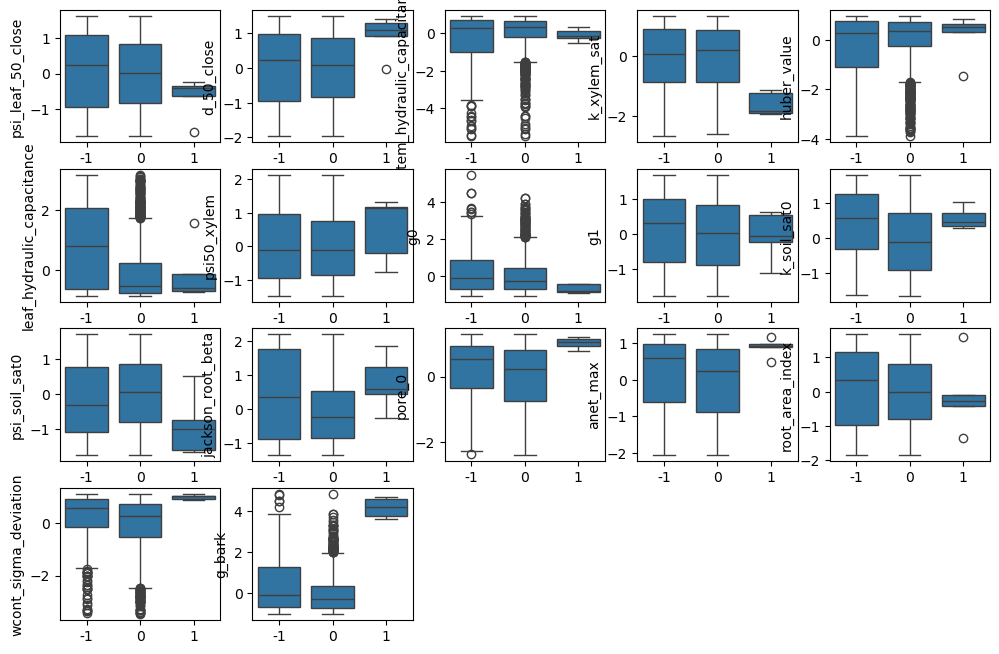

In [362]:
fig = plt.figure(figsize=(12, 10))
for index, var in zip(np.arange(1, len(variables) + 1), variables):
    ax = fig.add_subplot(5, 5, index)
    sns.boxplot(x=db.labels_, y=dfc[var], ax=ax)

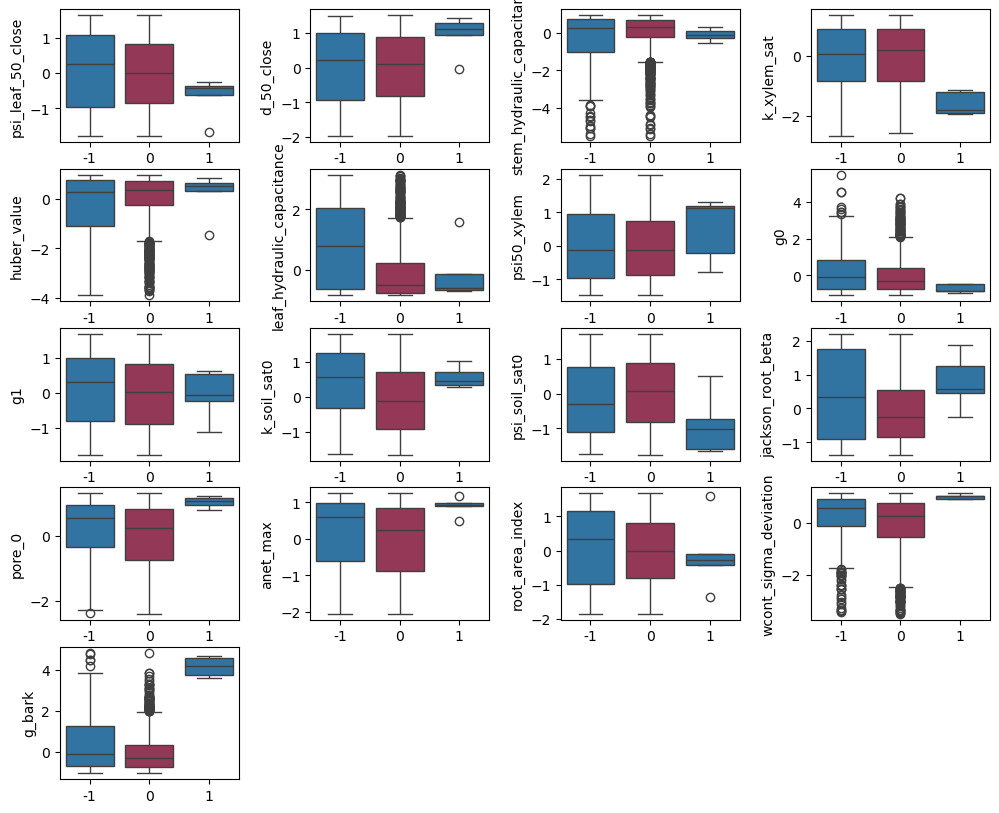

In [363]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(variables)+1), variables):
    ax = fig.add_subplot(5,4, index)
    sns.boxplot(x = db.labels_, y = dfc[var], ax=ax)
    for i in range(n_clusters_):
        box = ax.patches[i]
        if i > 0:
            box.set_facecolor(cmap(alive_means[i-1]))
plt.subplots_adjust(wspace=0.4)

In [313]:
# print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
# print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
# print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
# print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
# print(
#     "Adjusted Mutual Information:"
#     f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
# )


Silhouette Coefficient: 0.278
